# Project Title: E-Commerce Sales Performance & Data Integrity Optimization

### <center>Business Problem</center>

The company lacked a reliable way to analyze profitability across its 200,000+ 
multi-region sales records due to data inconsistencies, structural formatting errors, and unverified profit margins, 
which delayed key inventory and pricing decisions.

(A) Messy Raw Data: The company had a massive dataset of over 200,000 sales records, but it was filled with formatting bugs, trailing spaces, and hidden errors.

(B) Broken Reports: These data inconsistencies broke standard reporting tools, making it impossible to run accurate sales or profit metrics.

(C) Blind Decision-Making: Management couldn’t see which regions or product categories were actually making money, leading to a high risk of making bad inventory and pricing decisions.


In [ ]:
# Importing the necessary libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [7]:
# Load 200k raw sales records and strip hidden spaces from column names
df = pd.read_csv("product_sales_dataset_final.csv")
df

,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,08-23-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,12-20-24,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,01-29-24,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,11-29-24,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,09-21-23,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,199996,08-15-23,William Jackson,Boston,Massachusetts,East,United States,Home & Furniture,Storage,Storage Rack,4,254.42,1017.68,334.72
199996,199997,10-17-23,Sharon Ferrell,Bismarck,North Dakota,Centre,United States,Accessories,Small Electronics,Charging Cable,1,237.04,237.04,46.53
199997,199998,12-03-23,Katie Rivera,Santa Fe,New Mexico,West,United States,Accessories,Wearable Accessories,Sunglasses,2,106.83,213.66,102.57
199998,199999,12-08-23,Lisa Sullivan,New York City,New York,East,United States,Clothing & Apparel,Women's Wear,Zara Blouse,2,353.01,706.02,288.74


In [20]:
df = pd.read_csv("product_sales_dataset_final.csv")
# # Split into smaller tables (Corrected column names)
orders = df[['Order_ID', 'Order_Date']].drop_duplicates()
customers = df[['Customer_Name', 'City', 'State', 'Region', 'Country']].drop_duplicates()




In [27]:
orders.head(20)


,Order_ID,Order_Date
0,1,08-23-23
1,2,12-20-24
2,3,01-29-24
3,4,11-29-24
4,5,09-21-23
5,6,10-18-24
6,7,12-11-24
7,8,05-05-23
8,9,10-25-23
9,10,10-15-23


In [ ]:
customers.head(20)

,Customer_Name,City,State,Region,Country
0,Bianca Brown,Jackson,Mississippi,South,United States
1,Jared Edwards,Grand Rapids,Michigan,Centre,United States
2,Susan Valdez,Minneapolis,Minnesota,Centre,United States
3,Tina Williams,Tallahassee,Florida,South,United States
4,Catherine Gordon,Baltimore,Maryland,East,United States
5,Brittany Johnson,Boston,Massachusetts,East,United States
6,Katie Rodriguez MD,Seattle,Washington,West,United States
7,John Davis,Tulsa,Oklahoma,South,United States
8,Edward Hicks,Salt Lake City,Utah,West,United States
9,Carrie Cunningham,Fort Smith,Arkansas,South,United States


In [1]:
import pandas as pd

# 1. Load data and clean column spaces
df = pd.read_csv("product_sales_dataset_final.csv")
df.columns = df.columns.str.strip()

# 2. Top & Bottom Products by Revenue
product_sales = df.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False)

print("--- TOP 5 PRODUCTS ---")
print(product_sales.head(5).round(2))

print("\n--- BOTTOM 5 PRODUCTS ---")
print(product_sales.tail(5).round(2))

--- TOP 5 PRODUCTS ---
Product_Name
Tempur-Pedic Mattress    9061755.86
Instant Pot              8903475.26
MacBook Air              7362516.81
Apple Watch              6834472.35
Apple iPhone 14          5740819.18
Name: Revenue, dtype: float64

--- BOTTOM 5 PRODUCTS ---
Product_Name
Timberland Boots    1080391.29
Power Bank           998344.97
Watch Strap          946234.95
Belt                 761796.29
Tote Bag             669849.63
Name: Revenue, dtype: float64


# Profitability by Category

In [4]:
# Group by Category and sum the Profit
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(category_profit.round(2))

Category
Home & Furniture      11218596.44
Clothing & Apparel     8826851.49
Electronics            8065113.92
Accessories            3438046.28
Name: Profit, dtype: float64


# Regional Performance

In [5]:
# Group by Region and sum the Revenue
regional_revenue = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
print(regional_revenue.round(2))

Region
East      44980048.22
West      36242841.73
Centre    36081894.34
South     25102960.64
Name: Revenue, dtype: float64


# High-Volume Demand 


In [6]:
# Find the average quantity sold per order for each product
avg_qty = df.groupby('Product_Name')['Quantity'].mean().sort_values(ascending=False)
print(avg_qty.head(5))

Product_Name
Phone Case         2.252861
MacBook Air        2.232043
Instant Pot        2.102345
Apple iPhone 14    2.101760
Apple Watch        2.085314
Name: Quantity, dtype: float64


# Timeline / Growth Trend

In [10]:
# Convert date to datetime and group by year
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%m-%d-%y')
yearly_sales = df.groupby(df['Order_Date'].dt.year)['Revenue'].sum()
print(yearly_sales.round(2))

Order_Date
2023    70755372.66
2024    71652372.27
Name: Revenue, dtype: float64


# Monthly Revenue

In [ ]:
import pandas as pd

# Load data and fix dates
df = pd.read_csv("product_sales_dataset_final.csv")
df.columns = df.columns.str.strip()
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%m-%d-%y')

# Calculate monthly revenue
months = df.groupby(df['Order_Date'].dt.strftime('%B'))['Revenue'].sum()
print("--- MONTHLY REVENUE ---")
print(months.round(2))

--- MONTHLY REVENUE ---
Order_Date
April         8610953.51
August        8809139.98
December     20407679.60
February      5700418.66
January       8747247.48
July          8883257.91
June          9409983.38
March         7973781.40
May           9731544.05
November     27267751.80
October      17396936.97
September     9469050.19
Name: Revenue, dtype: float64


# Profit Margin by Sub-Category

In [11]:
# Calculate margin % for each sub-category
margins = (df.groupby('Sub_Category')['Profit'].sum() / df.groupby('Sub_Category')['Revenue'].sum()) * 100

print("--- MARGIN % BY SUB-CATEGORY ---")
print(margins.sort_values(ascending=False).round(2))

--- MARGIN % BY SUB-CATEGORY ---
Sub_Category
Bags                    34.12
Wearable Accessories    33.98
Small Electronics       33.90
Kids Wear               32.60
Sportswear              32.60
Women's Wear            32.52
Footwear                32.51
Men's Wear              32.42
Kitchenware             23.58
Storage                 23.54
Bedding                 23.52
Furniture               23.52
Home Decor              23.49
TVs & Audio             14.09
Smartphones             14.08
Tablets                 14.04
Wearables               14.03
Home Appliances         13.99
Laptops                 13.97
dtype: float64


# Average Order Value by Region

In [12]:
# Calculate average order size per region
region_aov = df.groupby('Region')['Revenue'].mean()

print("--- AVG ORDER VALUE BY REGION ---")
print(region_aov.sort_values(ascending=False).round(2))

--- AVG ORDER VALUE BY REGION ---
Region
East      788.65
Centre    727.41
South     661.74
West      653.87
Name: Revenue, dtype: float64


# Monthly Trend (Line Plot)

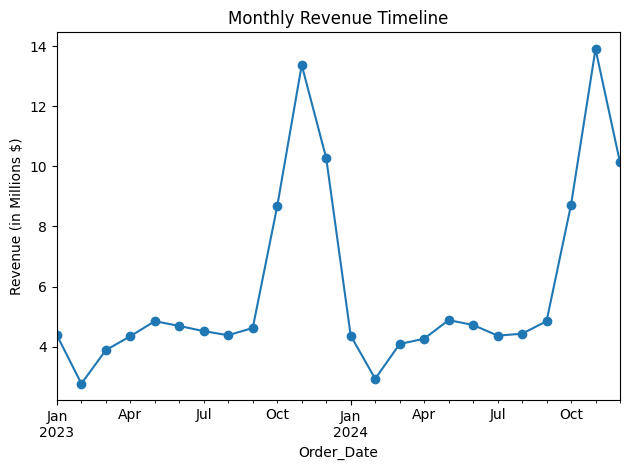

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data & parse dates
df = pd.read_csv("product_sales_dataset_final.csv")
df.columns = df.columns.str.strip()
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%m-%d-%y')

# 2. Resample by Month End ('ME') to avoid the warning
monthly = df.set_index('Order_Date').resample('ME')['Revenue'].sum() / 1e6

# 3. Plot simply
monthly.plot(marker='o')
plt.title("Monthly Revenue Timeline")
plt.ylabel("Revenue (in Millions $)")
plt.tight_layout()
plt.savefig("monthly_trend.png")

# Strategic Matrix (Revenue & Profit scaled to Millions)

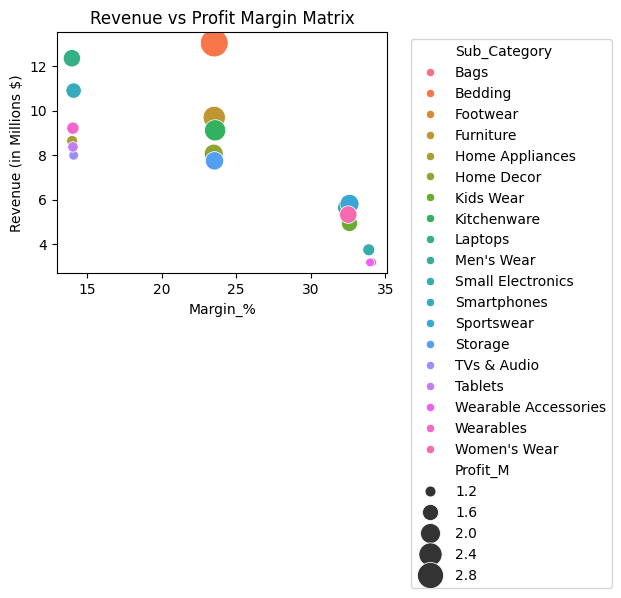

In [17]:
# Aggregate sales and convert large values to Millions
subcat = df.groupby('Sub_Category')[['Revenue', 'Profit']].sum().reset_index()
subcat['Margin_%'] = (subcat['Profit'] / subcat['Revenue']) * 100
subcat['Revenue_M'] = subcat['Revenue'] / 1e6
subcat['Profit_M'] = subcat['Profit'] / 1e6

# Plot Clean Bubbles
sns.scatterplot(data=subcat, x='Margin_%', y='Revenue_M', size='Profit_M', hue='Sub_Category', sizes=(40, 400))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Revenue vs Profit Margin Matrix")
plt.ylabel("Revenue (in Millions $)")
plt.tight_layout()
plt.savefig("subcategory_matrix.png")

# Regional Spread Density

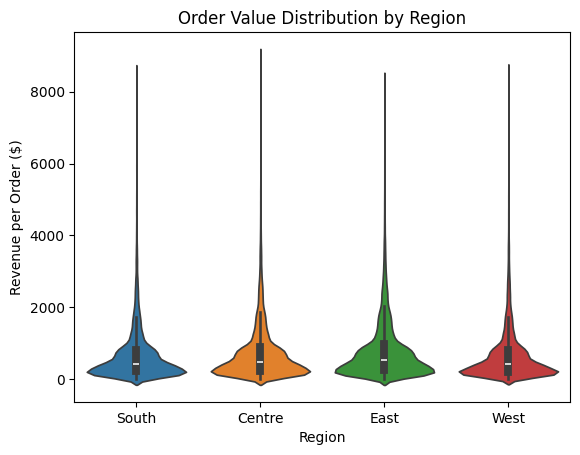

In [18]:
# Individual order values are smaller numbers, keeping them raw with a clean label
sns.violinplot(data=df, x='Region', y='Revenue', hue='Region')
plt.title("Order Value Distribution by Region")
plt.ylabel("Revenue per Order ($)")
plt.savefig("regional_distribution.png")

# Regional Cross-Tab Grid (Heatmap scaled to Millions)

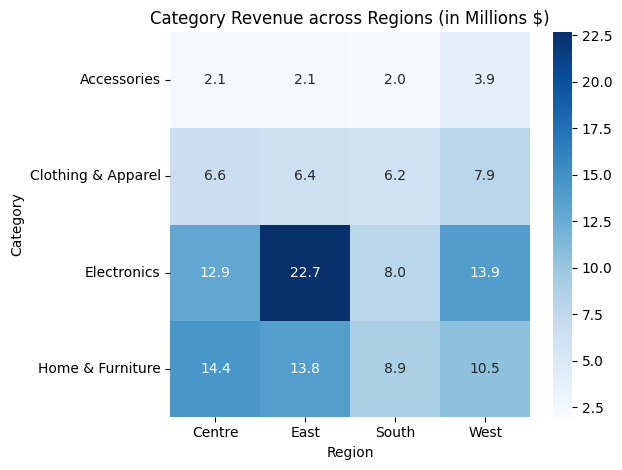

In [19]:
# Create pivot grid and divide entire matrix by 1 Million
pivot = df.pivot_table(index='Category', columns='Region', values='Revenue', aggfunc='sum') / 1e6

# Plot Clean Heatmap Grid
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues")
plt.title("Category Revenue across Regions (in Millions $)")
plt.tight_layout()
plt.savefig("category_region_heatmap.png")